## Workbook containing the proposed figures for chapter 1 

Table reporting of streamflow performance (NSE and KGE quartiles broken down by glaciation)

In [1]:
import numpy as np
import pandas as pd
from src.config import PROCESSED_DATA_DIR, OUTPUT_DATA_DIR, TEST_START_YEAR, TEST_END_YEAR

ENSEMBLE_MEMBERS = 10
model_list = ['area', 'baseline', 'topographic', 'phase-split']

# define the evaluation metrics (NSE, KGE, and PBIAS), robust to missing values (NaNs)
def nse(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    if not np.any(mask): return np.nan
    obs_masked = obs[mask]
    sim_masked = sim[mask]
    denom = np.sum((obs_masked - np.mean(obs_masked)) ** 2)
    if denom == 0: return np.nan
    return 1 - np.sum((obs_masked - sim_masked) ** 2) / denom

def kge(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    if not np.any(mask) or len(obs_masked := obs[mask]) < 2: return np.nan
    sim_masked = sim[mask]
    r = np.corrcoef(obs_masked, sim_masked)[0, 1]
    std_obs = np.std(obs_masked)
    mean_obs = np.mean(obs_masked)
    if std_obs == 0 or mean_obs == 0: return np.nan
    alpha = np.std(sim_masked) / std_obs
    beta = np.mean(sim_masked) / mean_obs
    return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

def pbias(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    if not np.any(mask): return np.nan
    obs_masked = obs[mask]
    denom = np.sum(obs_masked)
    if denom == 0: return np.nan
    return 100 * np.sum(sim[mask] - obs_masked) / denom

# load the ground truth data
static_atts = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0)
streamflow = pd.read_csv(PROCESSED_DATA_DIR / "combined_streamflow.csv", index_col=0)

# Convert the ground truth streamflow data to units of mm/day
streamflow.index = pd.to_datetime(streamflow.index)
test_years_mask = (streamflow.index.year >= TEST_START_YEAR) & (streamflow.index.year <= TEST_END_YEAR)
streamflow_test = streamflow.loc[test_years_mask]

# Align the static attributes order exactly with the streamflow columns
common_columns = streamflow_test.columns.intersection(static_atts.index)
streamflow_test = streamflow_test[common_columns]
areas = static_atts.loc[common_columns, 'basin_area_km2']

# Vectorized operation across all 290 columns at once
# (m3/s) / (km2 * 1e6) * 86400 s/day * 1000 mm/m -> mm/day
conversion_factor = 86400 * 1e3 / (areas * 1e6)
streamflow_mm = streamflow_test.multiply(conversion_factor, axis=1)

# Identify glaciated stations
glacier_col = [c for c in static_atts.columns if 'glacier_pct' in c.lower()][0]
glaciated_stations = static_atts[static_atts[glacier_col] > 0].index.intersection(streamflow_mm.columns)
all_stations = streamflow_mm.columns

# Container for final report records
summary_records = []

for model in model_list:
    # Storage arrays for metrics per member per station
    # Shape: (Ensemble_Members, Stations)
    member_kge_all = np.zeros((ENSEMBLE_MEMBERS, len(all_stations)))
    member_nse_all = np.zeros((ENSEMBLE_MEMBERS, len(all_stations)))
    member_pbias_all = np.zeros((ENSEMBLE_MEMBERS, len(all_stations)))
    
    # Track ensemble mean time-series prediction per station
    ens_mean_preds = pd.DataFrame(0.0, index=streamflow_mm.index, columns=all_stations)
    
    # 1. First Pass: Load all member predictions, calculate individual metrics, and build ensemble mean
    for i in range(ENSEMBLE_MEMBERS):
        file_fact = OUTPUT_DATA_DIR / model / f"{model}_preds_member_{i}.csv"
        # Assuming predictions columns match station IDs and rows match the date index
        preds = pd.read_csv(file_fact, index_col=0)
        preds.index = pd.to_datetime(preds.index)
        preds = preds.loc[streamflow_mm.index, all_stations] # Align perfectly
        
        ens_mean_preds += preds / ENSEMBLE_MEMBERS
        
        for s_idx, station in enumerate(all_stations):
            obs_series = streamflow_mm[station].values
            sim_series = preds[station].values
            member_kge_all[i, s_idx] = kge(obs_series, sim_series)
            member_nse_all[i, s_idx] = nse(obs_series, sim_series)
            member_pbias_all[i, s_idx] = pbias(obs_series, sim_series)

    # 2. Compute metrics for the actual Ensemble Mean time series
    ens_mean_kge_all = np.array([kge(streamflow_mm[st].values, ens_mean_preds[st].values) for st in all_stations])
    ens_mean_nse_all = np.array([nse(streamflow_mm[st].values, ens_mean_preds[st].values) for st in all_stations])
    ens_mean_pbias_all = np.array([pbias(streamflow_mm[st].values, ens_mean_preds[st].values) for st in all_stations])

    # 3. Aggregate metrics over spatial subsets (All vs. Glaciated)
    for subset_name, subset_stations in [("All Basins", all_stations), ("Glaciated Basins", glaciated_stations)]:
        # Get positional indices of subset stations relative to the 'all_stations' list
        sub_indices = [all_stations.get_loc(st) for st in subset_stations]
        
        # Individual member spatial aggregations
        sub_member_kge = np.nanmedian(member_kge_all[:, sub_indices], axis=1)
        sub_member_nse = np.nanmedian(member_nse_all[:, sub_indices], axis=1)
        sub_member_pbias = np.nanmedian(member_pbias_all[:, sub_indices], axis=1)
        
        sub_member_kge_gt07 = np.sum(member_kge_all[:, sub_indices] > 0.7, axis=1)
        sub_member_kge_lt0 = np.sum(member_kge_all[:, sub_indices] < 0.0, axis=1)
        
        # Ensemble mean spatial aggregations
        ens_mean_kge_med = np.nanmedian(ens_mean_kge_all[sub_indices])
        ens_mean_nse_med = np.nanmedian(ens_mean_nse_all[sub_indices])
        ens_mean_pbias_med = np.nanmedian(ens_mean_pbias_all[sub_indices])
        ens_mean_kge_gt07 = np.sum(ens_mean_kge_all[sub_indices] > 0.7)
        ens_mean_kge_lt0 = np.sum(ens_mean_kge_all[sub_indices] < 0.0)
        
        # Format strings as: Single Member Mean ± Std [Ensemble Mean Prediction value]
        def format_stat(member_arr, mean_val, is_int=False):
            fmt = "{:.0f}" if is_int else "{:.3f}"
            return f"{fmt.format(np.mean(member_arr))} ± {fmt.format(np.std(member_arr))} [{fmt.format(mean_val)}]"

        summary_records.append({
            "Model": model,
            "Subset": subset_name,
            "Median KGE": format_stat(sub_member_kge, ens_mean_kge_med),
            "Median NSE": format_stat(sub_member_nse, ens_mean_nse_med),
            "Median PBIAS (%)": format_stat(sub_member_pbias, ens_mean_pbias_med, is_int=False),
            "Stations KGE > 0.7": format_stat(sub_member_kge_gt07, ens_mean_kge_gt07, is_int=True),
            "Stations KGE < 0.0": format_stat(sub_member_kge_lt0, ens_mean_kge_lt0, is_int=True)
        })

# 4. Generate beautiful multi-index layout for clean terminal printing
df_res = pd.DataFrame(summary_records).set_index(["Subset", "Model"])

print("\n" + "="*95)
print("   STREAMFLOW MODEL BENCHMARK TEST SUMMARY")
print("   Format: Single Member Mean ± SD [Ensemble Mean Prediction Metric]")
print("="*95)
with pd.option_context('display.max_columns', None, 'display.width', 1000, 'display.colheader_justify', 'center'):
    print(df_res)
print("="*95 + "\n")


   STREAMFLOW MODEL BENCHMARK TEST SUMMARY
   Format: Single Member Mean ± SD [Ensemble Mean Prediction Metric]
                                   Median KGE             Median NSE             Median PBIAS (%)      Stations KGE > 0.7 Stations KGE < 0.0
Subset           Model                                                                                                                      
All Basins       area         0.491 ± 0.098 [0.526]  0.509 ± 0.075 [0.567]  -14.478 ± 10.332 [-12.535]     76 ± 16 [85]      30 ± 24 [17]   
Glaciated Basins area         0.767 ± 0.064 [0.794]  0.769 ± 0.064 [0.820]     -1.964 ± 5.470 [-1.232]     60 ± 11 [69]         0 ± 0 [0]   
All Basins       baseline     0.275 ± 0.302 [0.352]  0.349 ± 0.239 [0.453]  -31.906 ± 26.380 [-29.884]     49 ± 28 [44]      70 ± 64 [38]   
Glaciated Basins baseline     0.560 ± 0.290 [0.645]  0.570 ± 0.335 [0.735]  -18.232 ± 22.726 [-16.576]     40 ± 22 [37]        7 ± 16 [0]   
All Basins       topographic  0.688 ± 0.0

Define standard inputs

In [ ]:
# general variables and imports
import pandas as pd
import numpy as np
from src.config import PROCESSED_DATA_DIR, OUTPUT_DATA_DIR, OUTPUT_GLACIER_VOL_FILES

ENSEMBLE_MEMBERS = 10

# load observed streaflow and static attributes
df_obs = pd.read_csv(PROCESSED_DATA_DIR / "combined_streamflow.csv", index_col='Date', parse_dates=True)
df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0) 

# Convert streamflow to mm/day for KGE calculation
for stat in df_obs.columns:
    if stat in df_attr.index:
        area_km2 = df_attr.loc[stat, 'basin_area_km2']
        df_obs[stat] = df_obs[stat] * (86.4 / area_km2)

# load best model predictions and compute ensemble mean
best_model = 'topographic'
# best_model = 'phase-split'
df_preds = []
df_cf_preds = []
for i in range(ENSEMBLE_MEMBERS):
    file_fact = OUTPUT_DATA_DIR / best_model / f"{best_model}_preds_member_{i}.csv"
    file_cf = OUTPUT_DATA_DIR / best_model / f"{best_model}_preds_noglacier_member_{i}.csv"
    df_pred = pd.read_csv(file_fact, index_col=0)
    df_cf_pred = pd.read_csv(file_cf, index_col=0)
    df_pred.index = pd.to_datetime(df_pred.index)
    df_cf_pred.index = pd.to_datetime(df_cf_pred.index)
    df_preds.append(df_pred)
    df_cf_preds.append(df_cf_pred)
df_pred = pd.concat(df_preds).groupby(level=0).mean()
df_cf_pred = pd.concat(df_cf_preds).groupby(level=0).mean()

# load the mass balance modeled meltwater contribution for each station
df_mbs = []
for i in range(len(OUTPUT_GLACIER_VOL_FILES)):
    df_mbs.append(pd.read_csv(OUTPUT_GLACIER_VOL_FILES[i], index_col=0, parse_dates=True))
df_mb = pd.concat(df_mbs).groupby(level=0).mean()
df_mb_range = pd.concat(df_mbs).groupby(level=0).agg(['min', 'max'])

# create a list of stations that are glaciated and have valid predictions
glaciated_stations = df_attr[df_attr['glacier_pct'] > 0].index.intersection(df_mb.columns)
print(f"Total stations with predictions: {len(df_pred.columns)}")
print(f"Glaciated stations with predictions: {len(glaciated_stations)}")

# define delta-Q and mass balance predictions for glaciated stations
dq_pred = df_pred[glaciated_stations] - df_cf_pred[glaciated_stations]  # Predicted glacier contribution (mm/day)
mb_pred = df_mb[glaciated_stations]  # Modeled glacier contribution (mm/day)
mb_pred_range = df_mb_range[glaciated_stations]  # Range of modeled glacier contribution (MCM)

# generate ensemble range of dq
dq_preds = []
for i in range(ENSEMBLE_MEMBERS):
    dq_preds.append(df_preds[i][glaciated_stations] - df_cf_preds[i][glaciated_stations])
dq_pred_range = pd.concat(dq_preds).groupby(level=0).agg(['min', 'max'])

# convert to units of MCM
dq_pred_mcm = dq_pred.multiply(df_attr.loc[glaciated_stations, 'basin_area_km2'], axis=1) / 1e3
mb_pred_mcm = mb_pred.multiply(df_attr.loc[glaciated_stations, 'basin_area_km2'], axis=1) / 1e3

# convert to units of mm over glacier area
dq_pred_mm_glacier = dq_pred.divide((df_attr.loc[glaciated_stations, 'glacier_pct'] / 100), axis=1)
mb_pred_mm_glacier = mb_pred.divide((df_attr.loc[glaciated_stations, 'glacier_pct'] / 100), axis=1)

# perform imputation on the ground truth streamflow data
df_obs_imputed = df_obs.interpolate(method='linear', limit=7)
df_obs_imputed = df_obs_imputed.fillna(df_obs_imputed.groupby(df_obs_imputed.index.dayofyear).transform('mean'))
df_obs_imputed = df_obs_imputed.fillna(df_obs_imputed.min())
q_obs_filtered = df_obs_imputed[glaciated_stations]

def kge(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    if not np.any(mask) or len(obs_masked := obs[mask]) < 2: return np.nan
    sim_masked = sim[mask]
    r = np.corrcoef(obs_masked, sim_masked)[0, 1]
    std_obs = np.std(obs_masked)
    mean_obs = np.mean(obs_masked)
    if std_obs == 0 or mean_obs == 0: return np.nan
    alpha = np.std(sim_masked) / std_obs
    beta = np.mean(sim_masked) / mean_obs
    return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

Total stations with predictions: 269
Glaciated stations with predictions: 87


Sketch of counterfactual hypothesis

In [ ]:
# define example glacial station
glac_stat = '05DA009'
pred_pct_threshold = 0.9

# 1. Filter the attributes dataframe to only rows with 0% glacier coverage
# Keep this as a DataFrame instead of extracting the index immediately
candidate_stats = df_attr[df_attr['glacier_pct'] == 0].copy()

# 2. Calculate the data presence percentage for these specific stations
# df_obs[candidate_stats.index] isolates the observation columns we care about
candidate_stats['pred_pct'] = df_obs[candidate_stats.index].notna().mean()

# 3. Filter out stations that don't meet your data coverage threshold
candidate_stats = candidate_stats[candidate_stats['pred_pct'] >= pred_pct_threshold]

if candidate_stats.empty:
    raise ValueError("No non-glaciated stations meet the prediction coverage threshold.")

# 4. Grab target coordinates for the glacial station
glac_lat = df_attr.loc[glac_stat, 'latitude']
glac_lon = df_attr.loc[glac_stat, 'longitude']

# 5. Compute Euclidean distance using the vectors inside the DataFrame
candidate_stats['distance'] = np.sqrt(
    (candidate_stats['latitude'] - glac_lat)**2 + 
    (candidate_stats['longitude'] - glac_lon)**2
)

# 6. Sort by distance and grab the index (station ID) of the closest one
nearest_stat = candidate_stats.sort_values('distance').index[0]

print(f"Selected non-glaciated station for comparison: {nearest_stat}")

Selected non-glaciated station for comparison: 05DC006


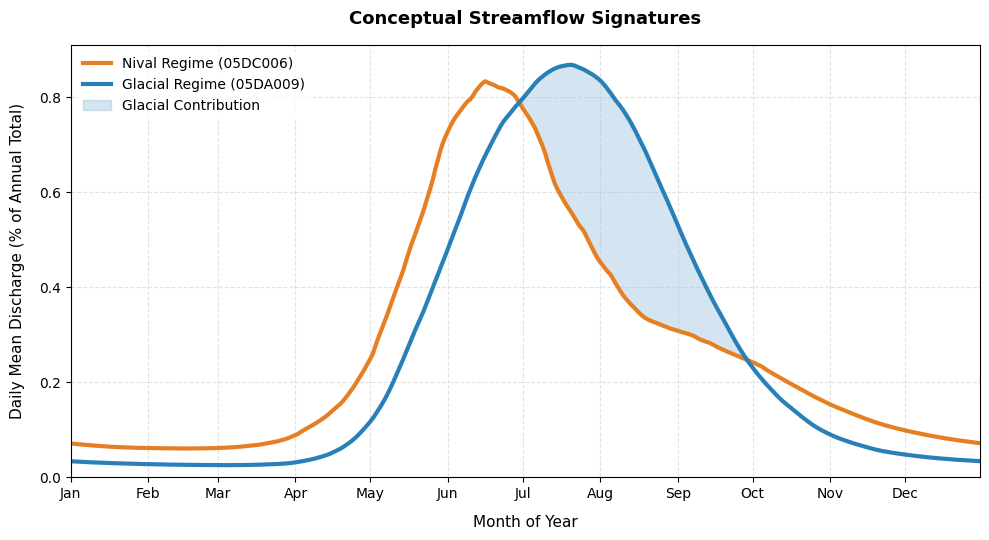

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure df_obs index is explicitly treated as a datetime format
df_obs.index = pd.to_datetime(df_obs.index)

df_historical = df_obs[[glac_stat, nearest_stat]]

# 1. Compute the multi-year daily mean (Calendar Year Climatology)
df_daily = df_historical.groupby([df_historical.index.month, df_historical.index.day]).mean()

# Handle February 29th cleanly if it exists
if (2, 29) in df_daily.index:
    df_daily = df_daily.drop(index=(2, 29))

# 2. Convert to Percentage of Annual Discharge
df_pct = (df_daily / df_daily.sum()) * 100

# 3. Cyclical Rolling Mean Smoothing
# Consecutively tile the 365-day series 3 times to handle the calendar edges cleanly
df_tripled = pd.concat([df_pct, df_pct, df_pct], ignore_index=True)

# Apply a 45-day rolling centered average
window_days = 45
df_rolled_tripled = df_tripled.rolling(window=window_days, center=True).mean()

# Extract the middle 365 days (the true calendar year with seamless edges)
n_days = len(df_pct)
df_smoothed = df_rolled_tripled.iloc[n_days : 2*n_days].copy()
df_smoothed.index = df_pct.index  # Restore the original month/day index

# 4. Plotting the final curves
plt.figure(figsize=(10, 5.5))
x = np.arange(len(df_smoothed))

y_nival = df_smoothed[nearest_stat].values
y_glacial = df_smoothed[glac_stat].values

# Plot the smooth signature lines
plt.plot(x, y_nival, label=f'Nival Regime ({nearest_stat})', color='#e67e22', lw=3)
plt.plot(x, y_glacial, label=f'Glacial Regime ({glac_stat})', color='#2980b9', lw=3)

# 5. Shade the specific region where Glacial > Nival (Late-Summer Glacial Augmentation)
plt.fill_between(
    x, y_glacial, y_nival, 
    where=(y_glacial > y_nival), 
    interpolate=True, 
    color='#2980b9', 
    alpha=0.2, 
    label='Glacial Contribution'
)

# Map the x-axis tick positions for Calendar Year
calendar_months = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

tick_locs = []
for m in calendar_months:
    indices = np.where(df_smoothed.index.get_level_values(0) == m)[0]
    if len(indices) > 0:
        tick_locs.append(indices[0])

plt.xticks(tick_locs, month_labels)

# Figure styling and formatting
plt.title('Conceptual Streamflow Signatures', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Month of Year', fontsize=11, labelpad=10)
plt.ylabel('Daily Mean Discharge (% of Annual Total)', fontsize=11, labelpad=10)
plt.grid(True, linestyle='--', alpha=0.35)
plt.xlim(0, len(df_smoothed) - 1)
plt.ylim(bottom=0)
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none', fontsize=10)

plt.tight_layout()
plt.show()

Streamflow model performance (NSE and KGE results)

Calculating KGE values on test set...
Computing hydrographs and clustering...
Generating Voronoi spatial grid...
Rendering final plot...


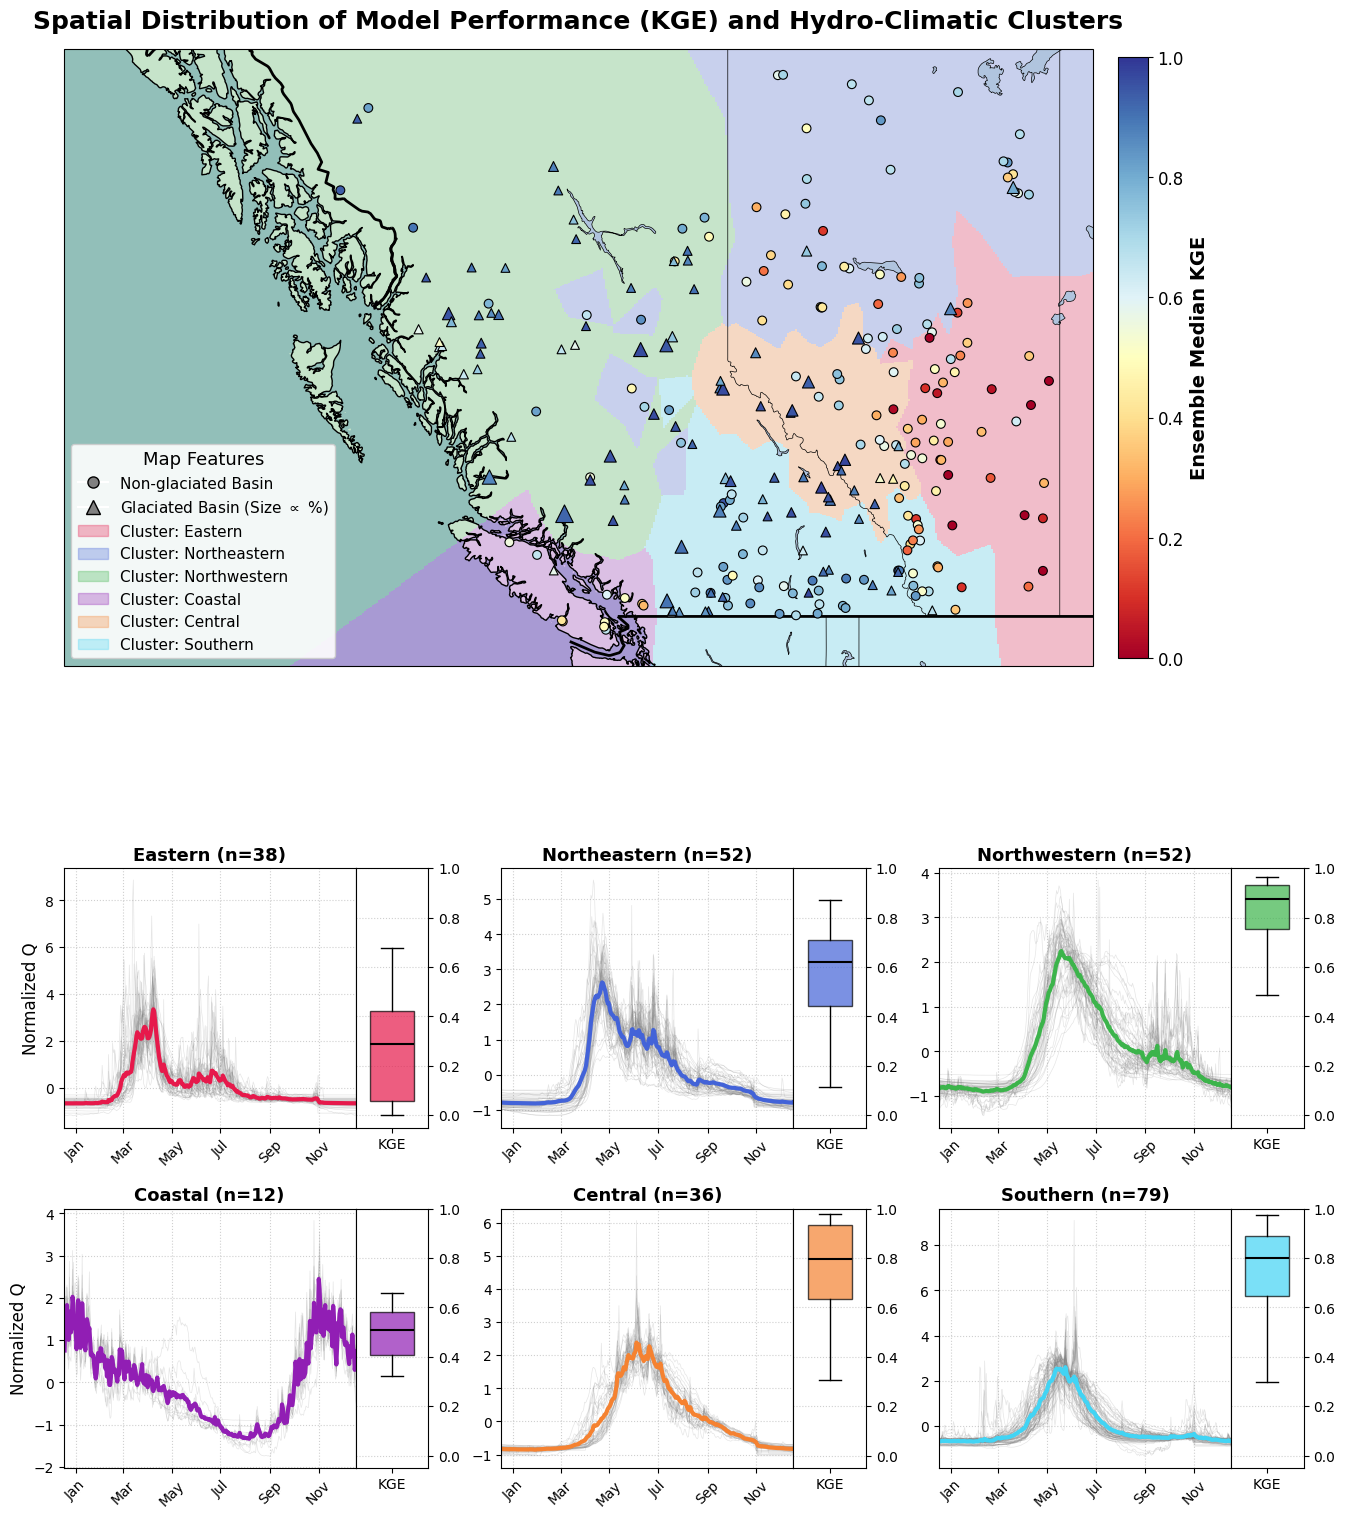

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.colors import ListedColormap
import pandas as pd
import numpy as np
import warnings
from src.config import TEST_START_YEAR, TEST_END_YEAR

warnings.filterwarnings('ignore')

# =========================================================
# 1. Temporal Filtering for KGE (Test Period Only)
# =========================================================
df_obs_test = df_obs[(df_obs.index.year >= TEST_START_YEAR) & (df_obs.index.year <= TEST_END_YEAR)]
df_pred_test = df_pred[(df_pred.index.year >= TEST_START_YEAR) & (df_pred.index.year <= TEST_END_YEAR)]

# =========================================================
# 2. Imputation for Hydrographs (Using ENTIRE Dataset)
# =========================================================
df_obs_imputed = df_obs.interpolate(method='linear', limit=7)
df_obs_imputed = df_obs_imputed.fillna(df_obs_imputed.groupby(df_obs_imputed.index.dayofyear).transform('mean'))
df_obs_imputed = df_obs_imputed.fillna(df_obs_imputed.min())

# =========================================================
# 3. Calculate KGE across Ensemble Mean (No Interpolation)
# =========================================================
print("Calculating KGE values on test set...")
all_stations = df_obs.columns
station_median_kge = {}

for stat in all_stations:
    if stat in df_pred_test.columns:
        obs_vals = df_obs_test[stat].values
        sim_vals = df_pred_test[stat].values
        stat_kge = kge(obs_vals, sim_vals)
        station_median_kge[stat] = np.clip(stat_kge, 0, 1)

df_kge = pd.DataFrame.from_dict(station_median_kge, orient='index', columns=['KGE'])
glacier_col = [c for c in df_attr.columns if 'glac' in c.lower()][0]

# =========================================================
# 4. Clustering (Using Hydrographs + Spatial Coordinates)
# =========================================================
print("Computing hydrographs and clustering...")
avg_hydrograph = df_obs_imputed.groupby(df_obs_imputed.index.dayofyear).mean()
avg_hydrograph_norm = (avg_hydrograph - avg_hydrograph.mean()) / avg_hydrograph.std()

X_hydro = avg_hydrograph_norm.T
X_merged = X_hydro.join(df_attr[['latitude', 'longitude']], how='inner')

hydro_features = X_merged.drop(columns=['latitude', 'longitude']).values
lat_norm = (X_merged['latitude'] - X_merged['latitude'].mean()) / X_merged['latitude'].std()
lon_norm = (X_merged['longitude'] - X_merged['longitude'].mean()) / X_merged['longitude'].std()

lat_features = np.tile(lat_norm.values, (182, 1)).T
lon_features = np.tile(lon_norm.values, (182, 1)).T

X_cluster_input = np.hstack((hydro_features, lat_features, lon_features))
Z = linkage(X_cluster_input, method='ward')
cluster_labels = fcluster(Z, t=6, criterion='maxclust') - 1

df_plot = pd.DataFrame({'Cluster': cluster_labels}, index=X_merged.index)
df_plot = df_plot.join(df_attr[['latitude', 'longitude', glacier_col]], how='inner')
df_plot = df_plot.rename(columns={glacier_col: 'glacier_pct'})
df_plot = df_plot.join(df_kge, how='inner')
df_plot['glacier_pct'] = df_plot['glacier_pct'].fillna(0)

cluster_names = {0: "Eastern", 1: "Northeastern", 2: "Northwestern", 3: "Coastal", 4: "Central", 5: "Southern"}
cluster_colors = ['#e6194B', '#4363d8', '#3cb44b', '#911eb4', '#f58231', '#42d4f4']
cmap_clusters = ListedColormap(cluster_colors)

# =========================================================
# 5. Generate Voronoi Grid (KNN Approach)
# =========================================================
print("Generating Voronoi spatial grid...")
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(df_plot[['longitude', 'latitude']], df_plot['Cluster'])

xx, yy = np.meshgrid(np.linspace(-140, -109, 500), np.linspace(48, 59, 500))
Z_grid = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z_grid = Z_grid.reshape(xx.shape)

# =========================================================
# 6. Plotting - Master Layout
# =========================================================
print("Rendering final plot...")

# Pre-calculate global lower limit for KGE boxplots (ignoring outliers)
global_min_whisker = 1.0
for cid in range(6):
    kge_vals = df_plot.loc[df_plot['Cluster'] == cid, 'KGE'].dropna()
    if not kge_vals.empty:
        q1 = kge_vals.quantile(0.25)
        q3 = kge_vals.quantile(0.75)
        iqr = q3 - q1
        lower_whisker = max(kge_vals.min(), q1 - 1.5 * iqr)
        global_min_whisker = min(global_min_whisker, lower_whisker)
        
# y_lower_bound = max(0.0, global_min_whisker - 0.05) # Add 0.05 padding, floor at 0
y_lower_bound = global_min_whisker - 0.05

fig = plt.figure(figsize=(16, 20))
gs = fig.add_gridspec(4, 3, height_ratios=[1.5, 1.5, 1, 1], hspace=0.25, wspace=0.2)

# --- PANEL A: The Map ---
ax_map = fig.add_subplot(gs[0:2, :], projection=ccrs.Mercator())
ax_map.set_extent([-140, -109, 48, 59], crs=ccrs.PlateCarree())

res = '10m' 
ax_map.add_feature(cfeature.LAND.with_scale(res), facecolor='whitesmoke', zorder=0)
ax_map.add_feature(cfeature.OCEAN.with_scale(res), facecolor='lightsteelblue', zorder=0)
ax_map.add_feature(cfeature.COASTLINE.with_scale(res), edgecolor='black', zorder=2)
ax_map.add_feature(cfeature.LAKES.with_scale(res), facecolor='lightsteelblue', edgecolor='black', linewidth=0.5, zorder=2)

provinces = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lines', scale=res, facecolor='none')
ax_map.add_feature(provinces, edgecolor='black', linewidth=0.5, zorder=3)
ax_map.add_feature(cfeature.BORDERS.with_scale(res), linestyle='-', edgecolor='black', linewidth=2.0, zorder=3)

# Plot Voronoi Shading
ax_map.pcolormesh(xx, yy, Z_grid, cmap=cmap_clusters, alpha=0.25, transform=ccrs.PlateCarree(), zorder=1)

# Plot Heatmap Points (Non-glaciated)
sc_non_glac = ax_map.scatter(
    df_plot[df_plot['glacier_pct'] == 0]['longitude'], 
    df_plot[df_plot['glacier_pct'] == 0]['latitude'],
    c=df_plot[df_plot['glacier_pct'] == 0]['KGE'],
    cmap='RdYlBu', vmin=0, vmax=1,
    s=40, marker='o', edgecolors='k', linewidths=0.8, transform=ccrs.PlateCarree(), zorder=5
)

# Plot Heatmap Points (Glaciated) scaled dynamically 
max_glacier = df_plot['glacier_pct'].max() if df_plot['glacier_pct'].max() > 0 else 1
glac_sizes = 40 + (df_plot[df_plot['glacier_pct'] > 0]['glacier_pct'] / max_glacier) * 120

sc_glac = ax_map.scatter(
    df_plot[df_plot['glacier_pct'] > 0]['longitude'], 
    df_plot[df_plot['glacier_pct'] > 0]['latitude'],
    c=df_plot[df_plot['glacier_pct'] > 0]['KGE'],
    cmap='RdYlBu', vmin=0, vmax=1,
    s=glac_sizes, 
    marker='^', edgecolors='k', linewidths=0.8, transform=ccrs.PlateCarree(), zorder=6
)

cbar = plt.colorbar(sc_non_glac, ax=ax_map, orientation='vertical', pad=0.02, shrink=0.7)
cbar.set_label('Ensemble Median KGE', fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

# Legend Configuration
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=8, markeredgecolor='k', label='Non-glaciated Basin'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markersize=10, markeredgecolor='k', label='Glaciated Basin (Size $\propto$ %)')
]
for i in range(6):
    legend_elements.append(mpatches.Patch(color=cluster_colors[i], alpha=0.3, label=f'Cluster: {cluster_names[i]}'))

ax_map.legend(handles=legend_elements, loc='lower left', title="Map Features", fontsize=11, title_fontsize=13, framealpha=0.9)
ax_map.set_title('Spatial Distribution of Model Performance (KGE) and Hydro-Climatic Clusters', fontsize=18, fontweight='bold', pad=15)

# --- PANEL B: The Hydrographs and KGE Boxplots ---
month_ticks = [15, 74, 135, 196, 258, 319]
month_labels = ['Jan', 'Mar', 'May', 'Jul', 'Sep', 'Nov']

for cluster_id in range(6):
    row = 2 + (cluster_id // 3)
    col = cluster_id % 3
    
    inner_gs = gs[row, col].subgridspec(1, 2, width_ratios=[4, 1], wspace=0.0)
    
    ax_hydro = fig.add_subplot(inner_gs[0])
    ax_box = fig.add_subplot(inner_gs[1])
    
    station_names = df_plot[df_plot['Cluster'] == cluster_id].index
    cluster_hydro_data = avg_hydrograph_norm[station_names]
    cluster_kge = df_plot.loc[station_names, 'KGE'].dropna()
    
    # -- 1. Plot Hydrograph --
    ax_hydro.plot(cluster_hydro_data.index, cluster_hydro_data.values, color='gray', alpha=0.2, linewidth=0.5)
    cluster_mean = cluster_hydro_data.mean(axis=1)
    ax_hydro.plot(cluster_mean.index, cluster_mean.values, color=cluster_colors[cluster_id], linewidth=3)
    
    ax_hydro.set_title(f"{cluster_names[cluster_id]} (n={len(station_names)})", fontsize=13, fontweight='bold')
    ax_hydro.set_xticks(month_ticks)
    ax_hydro.set_xticklabels(month_labels, rotation=45)
    ax_hydro.set_xlim(0, 365)
    ax_hydro.grid(True, linestyle=':', alpha=0.6)
    
    if col == 0:
        ax_hydro.set_ylabel('Normalized Q', fontsize=12)
        
    # -- 2. Plot Boxplot --
    box = ax_box.boxplot(cluster_kge, showfliers=False, widths=0.6, patch_artist=True)
    
    for patch in box['boxes']:
        patch.set_facecolor(cluster_colors[cluster_id])
        patch.set_alpha(0.7)
    for median in box['medians']:
        median.set(color='black', linewidth=1.5)
        
    # Apply calculated dynamic minimum bound
    ax_box.set_ylim(y_lower_bound, 1)
    ax_box.set_xticks([1])
    ax_box.set_xticklabels(['KGE'], fontsize=10)
    
    # Shift numerical ticks to the right side
    ax_box.yaxis.tick_right()
    ax_box.grid(True, axis='y', linestyle=':', alpha=0.6)
    ax_box.tick_params(axis='y', labelsize=10)

plt.show()

Counterfactual performance demonstration

Extracting data for Station 05DA009...
Calculating DL ensemble predictions and uncertainties...
Generating plots...


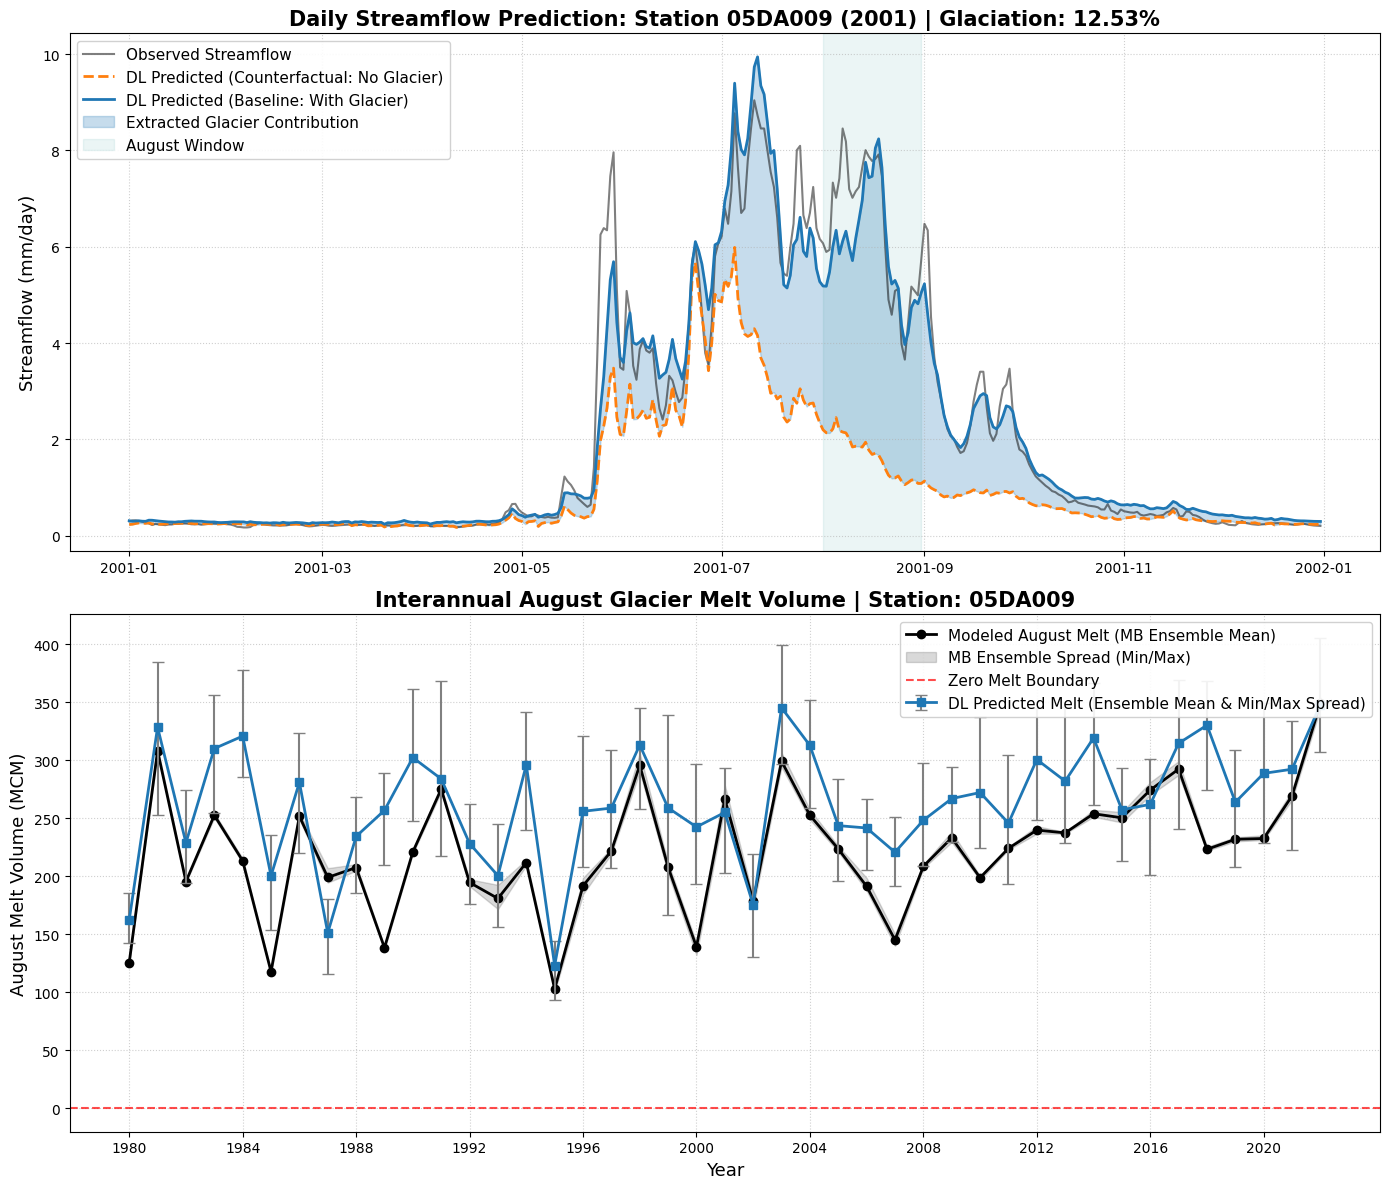

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# =========================================================
# 1. USER INPUTS
# =========================================================
TARGET_STATION = '05DA009'  # Change to explore different stations
TARGET_YEAR = 2001          # Change to explore different years

# =========================================================
# 2. Extract Target Data from Pre-loaded Environment
# =========================================================
print(f"Extracting data for Station {TARGET_STATION}...")

basin_area = df_attr.loc[TARGET_STATION, 'basin_area_km2']
glac_pct = df_attr.loc[TARGET_STATION, 'glacier_pct']

# Observations are already in mm/day per the environment template
obs_series = df_obs[TARGET_STATION]

# Extract and process the 3-member Mass Balance Ensemble
list_mb_aug_yearly = []
for mb_member in df_mbs:
    # Extract August data, and multiply by -1 to flip sign from mass loss to positive melt
    mb_aug = -mb_member[TARGET_STATION][mb_member.index.month == 8]
    mb_aug_sum = mb_aug.groupby(mb_aug.index.year).sum()
    list_mb_aug_yearly.append(mb_aug_sum)

# Aggregate MB ensemble
df_act_aug_yearly = pd.concat(list_mb_aug_yearly, axis=1)
act_aug_mcm_mean = df_act_aug_yearly.mean(axis=1)

# =========================================================
# 3. Process DL Ensemble Predictions and Uncertainty Spread
# =========================================================
print("Calculating DL ensemble predictions and uncertainties...")

list_aug_mcm_yearly = []

# Iterate through the pre-loaded lists of DL ensemble DataFrames
for pred_member, cf_member in zip(df_preds, df_cf_preds):
    pred = pred_member[TARGET_STATION]
    noglac = cf_member[TARGET_STATION]
    
    # Calculate yearly August MCM for this specific ensemble member
    diff_mm = pred - noglac
    aug_diff_mm = diff_mm[diff_mm.index.month == 8].groupby(diff_mm[diff_mm.index.month == 8].index.year).sum()
    
    # Convert mm over the basin to Million Cubic Meters (MCM)
    aug_mcm = aug_diff_mm * basin_area * 0.001
    list_aug_mcm_yearly.append(aug_mcm)

# Aggregate yearly August melt across the DL ensemble
df_aug_yearly = pd.concat(list_aug_mcm_yearly, axis=1)

# Extract deterministic daily means directly from the pre-computed templates
mean_pred_daily = df_pred[TARGET_STATION]
mean_noglac_daily = df_cf_pred[TARGET_STATION]

# --- Alignment and Uncertainty Calculations ---

# Ensure years align perfectly between DL predictions and MB ground truth
common_years = df_aug_yearly.index.intersection(act_aug_mcm_mean.index)

# 1. Subset DL predictions and calculate bounds
df_aug_yearly = df_aug_yearly.loc[common_years]
mean_aug_mcm = df_aug_yearly.mean(axis=1)
min_aug_mcm = df_aug_yearly.min(axis=1)
max_aug_mcm = df_aug_yearly.max(axis=1)

err_lower = mean_aug_mcm - min_aug_mcm
err_upper = max_aug_mcm - mean_aug_mcm
dl_yerr = [err_lower.values, err_upper.values]

# 2. Subset MB predictions and calculate bounds
df_act_aug_yearly = df_act_aug_yearly.loc[common_years]
act_aug_mcm_mean = act_aug_mcm_mean.loc[common_years]
act_min_aug_mcm = df_act_aug_yearly.min(axis=1)
act_max_aug_mcm = df_act_aug_yearly.max(axis=1)

# =========================================================
# 4. Plotting
# =========================================================
print("Generating plots...")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [1, 1]})

# ---------------------------------------------------------
# PANEL 1: Daily Hydrograph with Shaded Glacier Contribution
# ---------------------------------------------------------
year_mask = mean_pred_daily.index.year == TARGET_YEAR
dates_yr = mean_pred_daily[year_mask].index

pred_yr = mean_pred_daily[year_mask]
noglac_yr = mean_noglac_daily[year_mask]
obs_yr = obs_series[year_mask]

ax1.plot(dates_yr, obs_yr, color='black', alpha=0.5, label='Observed Streamflow', linewidth=1.5)
ax1.plot(dates_yr, noglac_yr, color='tab:orange', linestyle='--', label='DL Predicted (Counterfactual: No Glacier)', linewidth=2)
ax1.plot(dates_yr, pred_yr, color='tab:blue', label='DL Predicted (Baseline: With Glacier)', linewidth=2)

# Shade the area ONLY where With Glacier > Without Glacier
ax1.fill_between(dates_yr, noglac_yr, pred_yr, where=(pred_yr > noglac_yr), 
                 interpolate=True, color='tab:blue', alpha=0.25, label='Extracted Glacier Contribution')

# Highlight August Window
aug_start = pd.to_datetime(f"{TARGET_YEAR}-08-01")
aug_end = pd.to_datetime(f"{TARGET_YEAR}-08-31")
ax1.axvspan(aug_start, aug_end, color='teal', alpha=0.08, label='August Window')

ax1.set_title(f"Daily Streamflow Prediction: Station {TARGET_STATION} ({TARGET_YEAR}) | Glaciation: {glac_pct:.2f}%", fontsize=15, fontweight='bold')
ax1.set_ylabel("Streamflow (mm/day)", fontsize=13)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper left', fontsize=11, framealpha=0.9)

# ---------------------------------------------------------
# PANEL 2: Interannual August Melt Time Series w/ Bounds
# ---------------------------------------------------------
years = common_years.values

# Plot the Actual Mass Balance (Ground Truth) with Shaded Uncertainty
ax2.plot(years, act_aug_mcm_mean.values, color='black', marker='o', linestyle='-', linewidth=2, markersize=6, label='Modeled August Melt (MB Ensemble Mean)')
ax2.fill_between(years, act_min_aug_mcm.values, act_max_aug_mcm.values, color='black', alpha=0.15, label='MB Ensemble Spread (Min/Max)')

# Plot the DL Predicted Mean with Ensemble Error Bars
ax2.errorbar(years, mean_aug_mcm.values, yerr=dl_yerr, fmt='s-', color='tab:blue', linewidth=2, capsize=4, 
             ecolor='gray', elinewidth=1.5, markersize=6, label='DL Predicted Melt (Ensemble Mean & Min/Max Spread)')

ax2.axhline(0, color='red', linestyle='--', alpha=0.7, label='Zero Melt Boundary')

ax2.set_title(f"Interannual August Glacier Melt Volume | Station: {TARGET_STATION}", fontsize=15, fontweight='bold')
ax2.set_ylabel("August Melt Volume (MCM)", fontsize=13)
ax2.set_xlabel("Year", fontsize=13)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper right', fontsize=11, framealpha=0.9)

# Fix x-axis ticks to show round years cleanly
ax2.set_xticks(np.arange(min(years), max(years)+1, 4))

plt.tight_layout()
plt.show()

SOM cluster patterns

Extracting data and setting up specific yield...
Building datasets (Climatology Mode: False)...
Running SOM clustering (2x2 grid) on N=3741 samples...
Cluster assignments successfully saved to 'df_som_clusters' in memory.
Generating topological cluster plots...


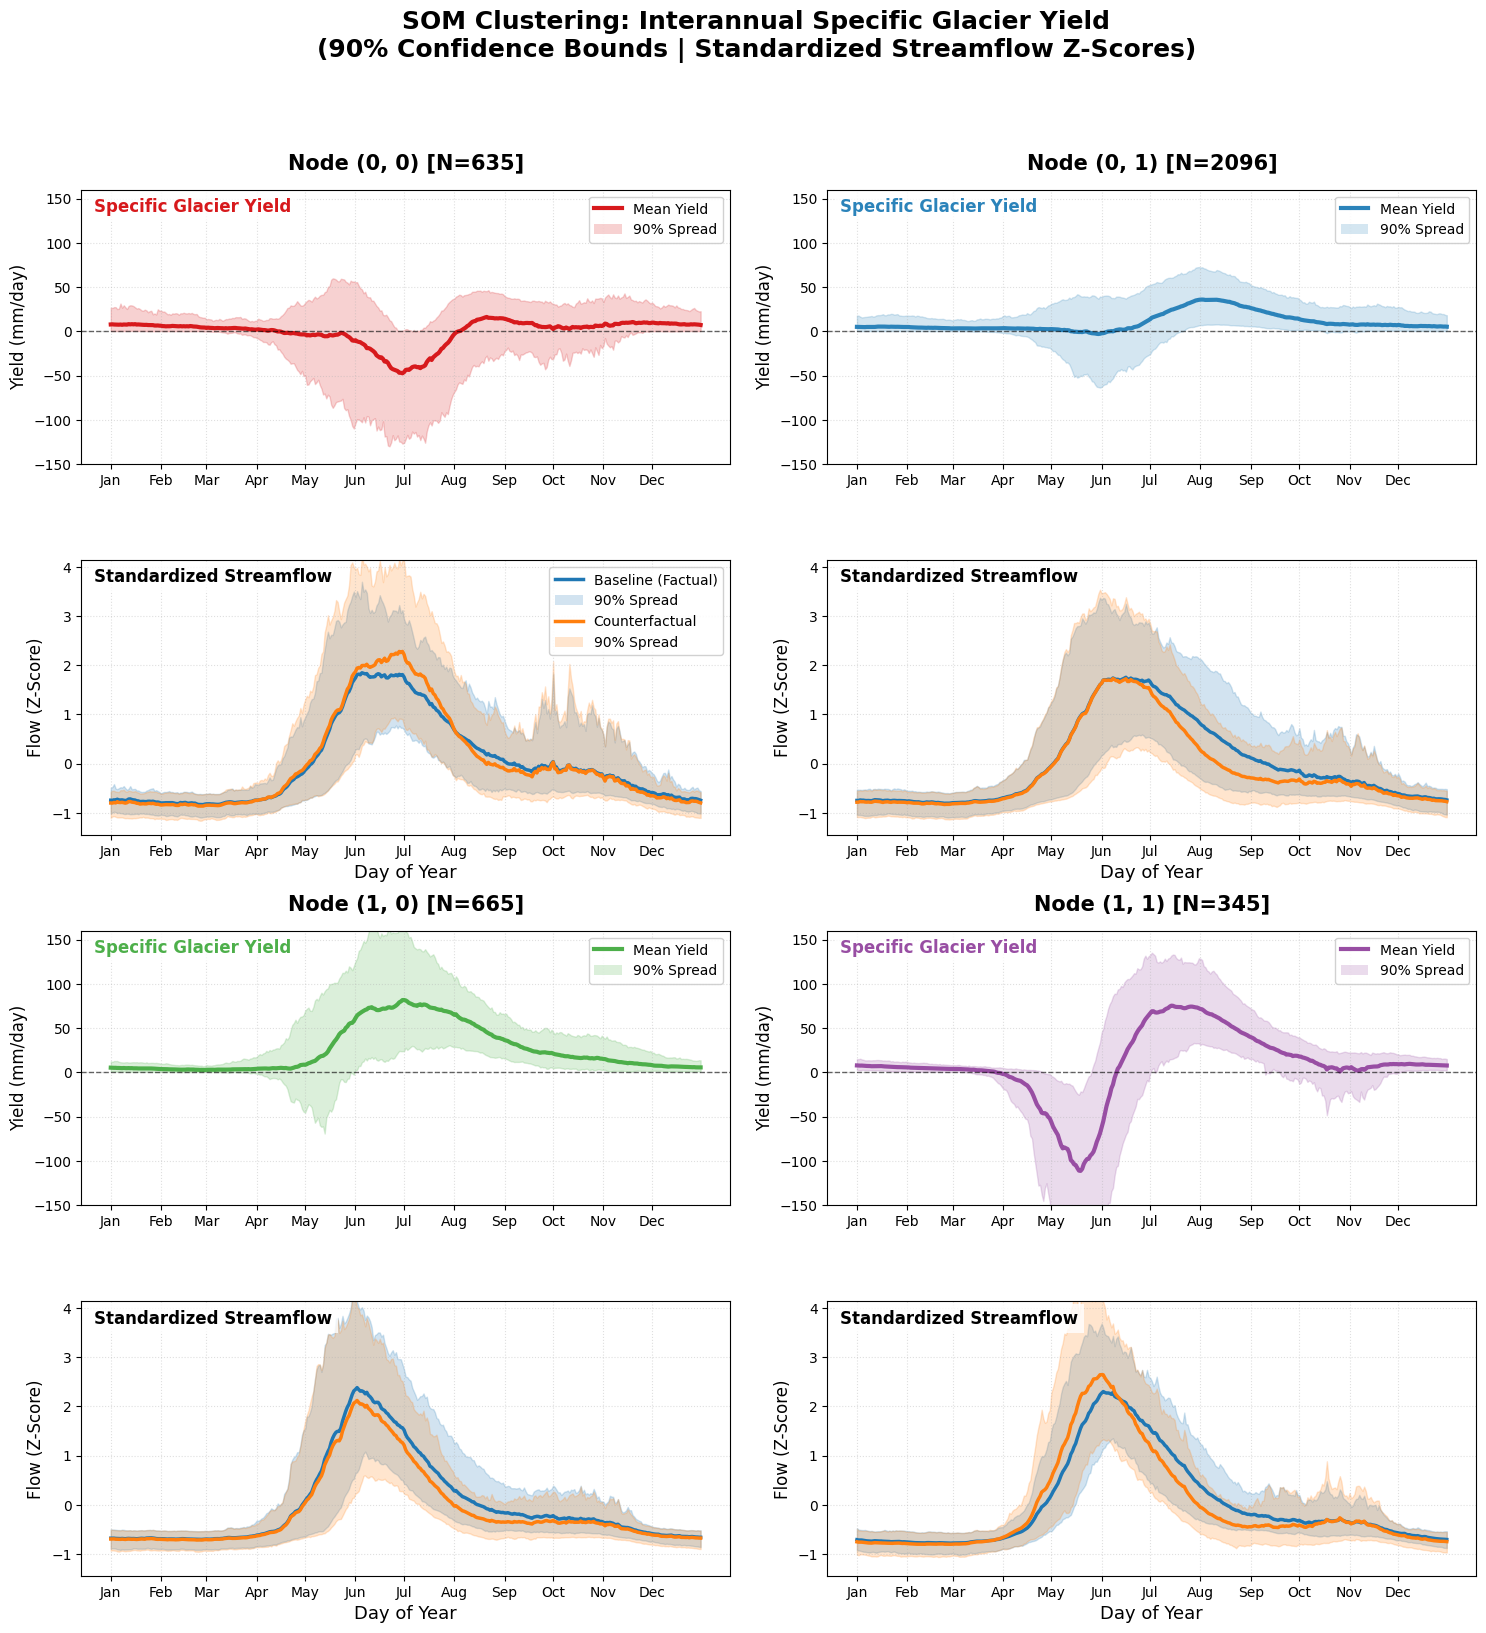

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from minisom import MiniSom
import warnings
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')

# =========================================================
# 1. USER INPUTS & TOGGLES
# =========================================================
# Set to True: Cluster on the 43-year average hydrograph for each station (N ~ 87)
# Set to False: Cluster on every individual station-year combination (N ~ 87 * 43)
CLUSTER_CLIMATOLOGY = False

# =========================================================
# 2. Establish Target Variables from Environment
# =========================================================
print("Extracting data and setting up specific yield...")

test_dates = df_pred.index
years = np.unique(test_dates.year)

# =========================================================
# 3. Build Datasets (Applying the Climatology Toggle)
# =========================================================
print(f"Building datasets (Climatology Mode: {CLUSTER_CLIMATOLOGY})...")

X_raw = [] # Specific Glacier Yield (mm/day)
P_raw = [] # Baseline Basin Streamflow (df_pred)
N_raw = [] # Counterfactual Basin Streamflow (df_cf_pred)
metadata = []

if CLUSTER_CLIMATOLOGY:
    # Remove leap days to ensure clean 365-day averaging
    dq_no_leap = dq_pred_mm_glacier[dq_pred_mm_glacier.index.dayofyear != 366]
    p_no_leap = df_pred[glaciated_stations][df_pred.index.dayofyear != 366]
    n_no_leap = df_cf_pred[glaciated_stations][df_cf_pred.index.dayofyear != 366]
    
    # Calculate the climatological mean for each day of the year
    X_clim = dq_no_leap.groupby(dq_no_leap.index.dayofyear).mean()
    P_clim = p_no_leap.groupby(p_no_leap.index.dayofyear).mean()
    N_clim = n_no_leap.groupby(n_no_leap.index.dayofyear).mean()
    
    for stat in glaciated_stations:
        dq_vals = X_clim[stat].values
        p_vals = P_clim[stat].values
        n_vals = N_clim[stat].values
        
        # Filter stations with negligible historical glacier contribution
        if np.nanmax(dq_vals) > 0.05:
            X_raw.append(dq_vals)
            P_raw.append(p_vals)
            N_raw.append(n_vals)
            metadata.append({'Station': stat, 'Type': 'Climatological Mean'})

else:
    for year in years:
        mask = test_dates.year == year
        
        dq_year = dq_pred_mm_glacier[mask]
        p_year = df_pred[glaciated_stations][mask]
        n_year = df_cf_pred[glaciated_stations][mask]
        
        for stat in glaciated_stations:
            dq_vals = dq_year[stat].values
            p_vals = p_year[stat].values
            n_vals = n_year[stat].values
            
            # Standardize arrays to non-leap year length
            if len(p_vals) == 366:
                dq_vals = dq_vals[:-1]
                p_vals = p_vals[:-1]
                n_vals = n_vals[:-1]
                
            if len(p_vals) == 365:
                if np.nanmax(dq_vals) > 0.05:
                    X_raw.append(dq_vals)
                    P_raw.append(p_vals)
                    N_raw.append(n_vals)
                    metadata.append({'Station': stat, 'Year': year})

X = np.array(X_raw)
P = np.array(P_raw)
N = np.array(N_raw)

# --- STANDARDIZATION ---
# 1. Per-Sample Standardization for the Streamflow plots (Z-Scores)
P_mean = np.mean(P, axis=1, keepdims=True)
P_std = np.std(P, axis=1, keepdims=True)
P_std[P_std == 0] = 1e-6 

P_scaled = (P - P_mean) / P_std
N_scaled = (N - P_mean) / P_std

# 2. Global Standardization for the SOM input (Preserves magnitude differences while aiding convergence)
# X_train = (X - np.mean(X)) / np.std(X)
X_train = X

# =========================================================
# 4. SOM Clustering
# =========================================================
grid_x, grid_y = 2, 2
k = grid_x * grid_y

print(f"Running SOM clustering ({grid_x}x{grid_y} grid) on N={len(X_train)} samples...")

som = MiniSom(x=grid_x, y=grid_y, input_len=X_train.shape[1], sigma=0.5, learning_rate=0.2, random_seed=42)
som.pca_weights_init(X_train)
som.train_random(X_train, num_iteration=5000)

winner_coords = np.array([som.winner(x) for x in X_train])
labels = winner_coords[:, 0] * grid_y + winner_coords[:, 1]

# =========================================================
# 5. Save Clusters to Dataframe
# =========================================================
df_som_clusters = pd.DataFrame(metadata)
df_som_clusters['Cluster'] = labels
print("Cluster assignments successfully saved to 'df_som_clusters' in memory.")

# =========================================================
# 6. Plotting (Mapped Topological 2x2 Layout)
# =========================================================
print("Generating topological cluster plots...")

cluster_colors = {
    0: '#d7191c',  # Red
    1: '#2b83ba',  # Blue
    2: '#4daf4a',  # Green
    3: '#984ea3'   # Purple
}

fig, axes = plt.subplots(4, 2, figsize=(18, 18))

title_prefix = "Climatological" if CLUSTER_CLIMATOLOGY else "Interannual"
fig.suptitle(f"SOM Clustering: {title_prefix} Specific Glacier Yield\n(90% Confidence Bounds | Standardized Streamflow Z-Scores)", fontsize=18, fontweight='bold', y=0.98)

x_days = np.arange(1, 366)
month_ticks = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Pre-calculate global axis limits based on percentiles to align scales properly
# yield_ymin = np.percentile(X, 1)*2
# yield_ymax = np.percentile(X, 99)*2
yield_ymin = -150
yield_ymax = 160

str_ymin = min(np.percentile(P_scaled, 5), np.percentile(N_scaled, 5)) - 0.5
str_ymax = max(np.percentile(P_scaled, 95), np.percentile(N_scaled, 95)) + 2

for i in range(k):
    qx = i // grid_y
    qy = i % grid_y
    
    row_yield = qx * 2
    row_str   = qx * 2 + 1
    col       = qy
    
    ax_diff = axes[row_yield, col]
    ax_abs  = axes[row_str, col]
    
    # Extract grouped data (Plotting Physical X, not X_train)
    diff_data = X[labels == i]              # Specific Yield (mm/day)
    p_data    = P_scaled[labels == i]       # Sample-standardized Factual
    n_data    = N_scaled[labels == i]       # Sample-standardized Counterfactual
    n_samples = len(diff_data)
    
    c_color = cluster_colors[i]
    
    if n_samples == 0:
        ax_diff.set_title(f"Node ({qx}, {qy}) - Empty Cluster", fontsize=13)
        ax_abs.axis('off')
        continue
    
    # --- TOP PLOT: Specific Glacier Yield (mm/day) ---
    diff_mean = np.mean(diff_data, axis=0)
    diff_lower, diff_upper = np.percentile(diff_data, [5, 95], axis=0)
    
    ax_diff.fill_between(x_days, diff_lower, diff_upper, color=c_color, alpha=0.2)
    ax_diff.plot(x_days, diff_mean, color=c_color, linewidth=3, label='Mean Yield')
    ax_diff.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.6)
    
    ax_diff.set_title(f"Node ({qx}, {qy}) [N={n_samples}]", fontsize=15, fontweight='bold', pad=15)
    ax_diff.text(0.02, 0.92, "Specific Glacier Yield", transform=ax_diff.transAxes, fontsize=12, fontweight='bold', color=c_color, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    
    # Apply unified Y-axis limits and X-axis ticks
    ax_diff.set_ylim(yield_ymin, yield_ymax)
    ax_diff.set_xticks(month_ticks)
    ax_diff.set_xticklabels(month_labels)
    
    ax_diff.grid(True, linestyle=':', alpha=0.4)
    ax_diff.set_ylabel("Yield (mm/day)", fontsize=12)
    
    custom_diff = [Line2D([0], [0], color=c_color, lw=3), Patch(facecolor=c_color, alpha=0.2)]
    ax_diff.legend(custom_diff, ['Mean Yield', '90% Spread'], loc='upper right', framealpha=0.9)
    
    # --- BOTTOM PLOT: Standardized Streamflow ---
    p_mean = np.mean(p_data, axis=0)
    n_mean = np.mean(n_data, axis=0)
    
    p_lower, p_upper = np.percentile(p_data, [5, 95], axis=0)
    n_lower, n_upper = np.percentile(n_data, [5, 95], axis=0)
    
    ax_abs.fill_between(x_days, p_lower, p_upper, color='tab:blue', alpha=0.2)
    ax_abs.plot(x_days, p_mean, color='tab:blue', linewidth=2.5, label='Baseline Mean')
    
    ax_abs.fill_between(x_days, n_lower, n_upper, color='tab:orange', alpha=0.2)
    ax_abs.plot(x_days, n_mean, color='tab:orange', linewidth=2.5, label='Counterfactual Mean')
    
    ax_abs.text(0.02, 0.92, "Standardized Streamflow", transform=ax_abs.transAxes, fontsize=12, fontweight='bold', color='black', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    
    # Apply unified Y-axis limits
    ax_abs.set_ylim(str_ymin, str_ymax)
    ax_abs.set_xticks(month_ticks)
    ax_abs.set_xticklabels(month_labels)
    
    ax_abs.grid(True, linestyle=':', alpha=0.4)
    ax_abs.set_ylabel("Flow (Z-Score)", fontsize=12)
    ax_abs.set_xlabel("Day of Year", fontsize=13)
    
    if i == 0: 
        custom_abs = [
            Line2D([0], [0], color='tab:blue', lw=2.5), Patch(facecolor='tab:blue', alpha=0.2),
            Line2D([0], [0], color='tab:orange', lw=2.5), Patch(facecolor='tab:orange', alpha=0.2)
        ]
        ax_abs.legend(custom_abs, ['Baseline (Factual)', '90% Spread', 'Counterfactual', '90% Spread'], loc='upper right', framealpha=0.9)

plt.subplots_adjust(hspace=0.35, wspace=0.15)
plt.show()

Extracting SOM clusters and metadata from environment variables...
Loading basin boundaries from GeoPackages...
  -> Successfully loaded MDA_ADP_05.gpkg (1740 basins)
  -> Successfully loaded MDA_ADP_07.gpkg (476 basins)
  -> Successfully loaded MDA_ADP_08.gpkg (2180 basins)
Successfully matched and sorted 87 basin polygons.
Fetching geographic boundaries...
Rendering map...


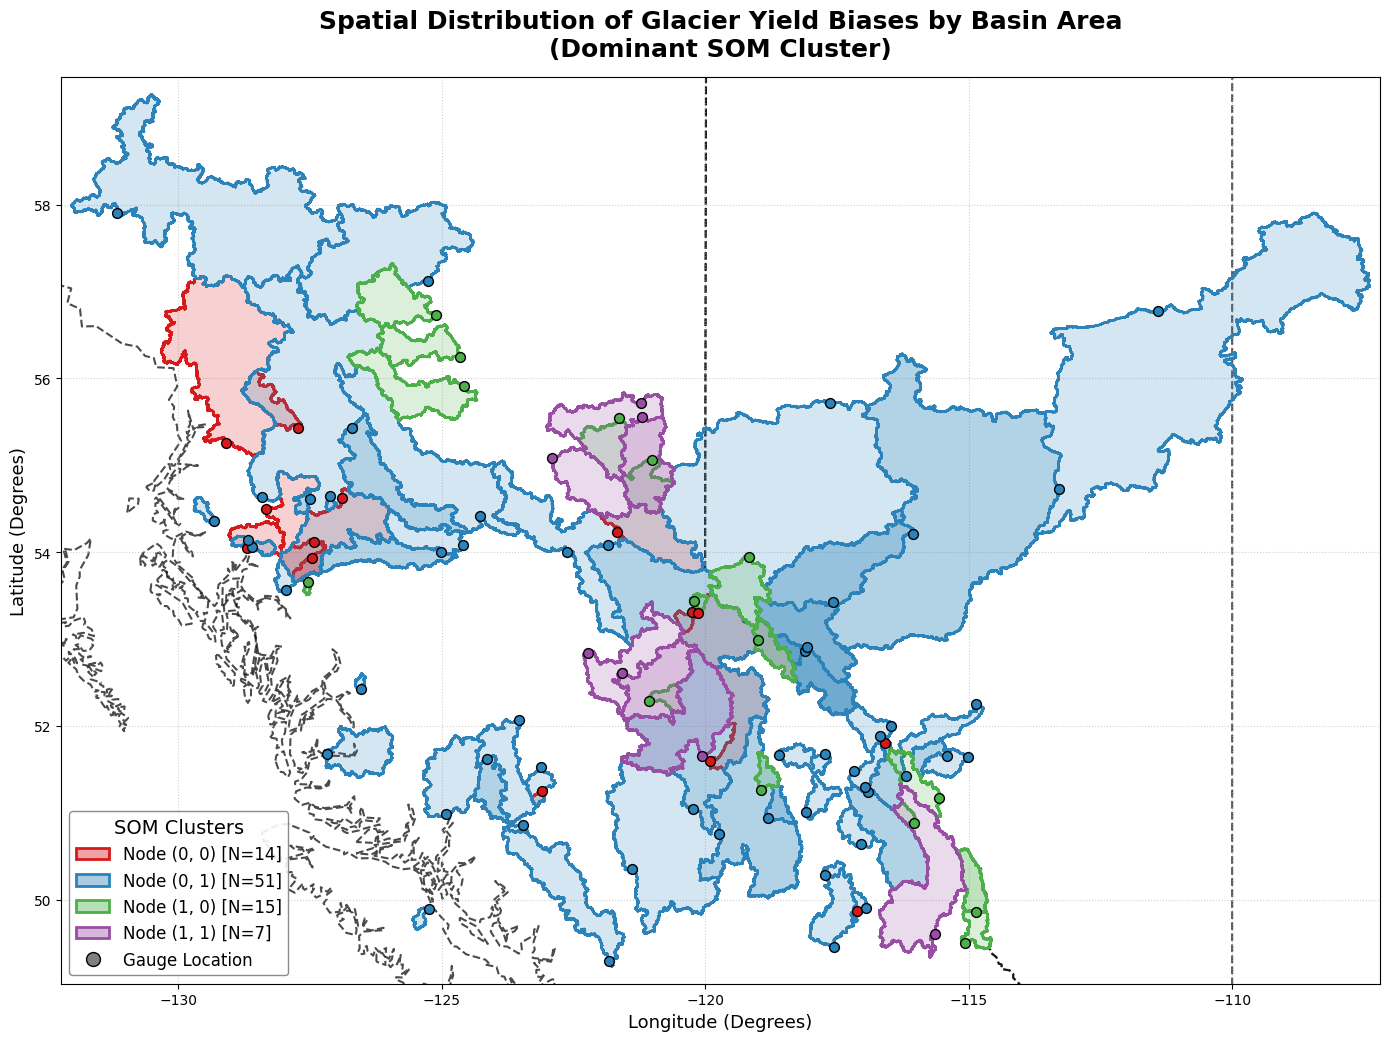

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import warnings
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from src.config import RAW_DATA_DIR

warnings.filterwarnings('ignore')

# =========================================================
# 1. Load Station Metadata and SOM Clusters
# =========================================================
print("Extracting SOM clusters and metadata from environment variables...")

# Use the in-memory dataframe generated by the clustering script
df_dominant = df_som_clusters.groupby('Station')['Cluster'].agg(lambda x: x.mode()[0]).reset_index()
df_dominant['Station'] = df_dominant['Station'].astype(str).str.strip().str.upper()

# Pull coordinates directly from the pre-loaded attributes dataframe
df_geo = df_attr[['latitude', 'longitude']].copy()
df_geo.index = df_geo.index.astype(str).str.strip().str.upper()
df_geo = df_geo.rename(columns={'latitude': 'Latitude', 'longitude': 'Longitude'})

# Merge to get Lat/Lon points for the clusters
df_map = pd.merge(df_dominant, df_geo, left_on='Station', right_index=True, how='inner')

# Create a GeoDataFrame for the Gauge Points
gdf_points = gpd.GeoDataFrame(
    df_map, 
    geometry=gpd.points_from_xy(df_map['Longitude'], df_map['Latitude']),
    crs="EPSG:4326"
)

# =========================================================
# 2. Load and Combine Basin Geometries (GeoPackages)
# =========================================================
print("Loading basin boundaries from GeoPackages...")

gpkg_files = ["MDA_ADP_05.gpkg", "MDA_ADP_07.gpkg", "MDA_ADP_08.gpkg"]
gdfs = []

for file_name in gpkg_files:
    file_path = RAW_DATA_DIR / "drainage_areas" / file_name
    try:
        gdf_part = gpd.read_file(file_path)
        gdfs.append(gdf_part)
        print(f"  -> Successfully loaded {file_name} ({len(gdf_part)} basins)")
    except Exception as e:
        print(f"  -> ⚠️ Failed to load {file_name}: {e}")

if not gdfs:
    raise FileNotFoundError("Could not load any basin geometries. Please check the file paths.")

gdf_basins = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs=gdfs[0].crs)

possible_cols = ['station_id', 'station', 'id', 'station_number', 'stationnum']
station_col = next((c for c in gdf_basins.columns if c.lower() in possible_cols), None)

if station_col:
    gdf_basins[station_col] = gdf_basins[station_col].astype(str).str.strip().str.upper()
else:
    raise ValueError("Could not find a station ID column in your basin shapefiles.")

# Merge the polygons with the cluster assignments
gdf_cluster_basins = gdf_basins.merge(df_map, left_on=station_col, right_on='Station', how='inner')

# --- Calculate area and sort so smallest basins plot on top ---
# We temporarily project to a meter-based CRS (Web Mercator) to get an accurate area metric
gdf_cluster_basins['calc_area'] = gdf_cluster_basins.to_crs("EPSG:3857").geometry.area
gdf_cluster_basins = gdf_cluster_basins.sort_values(by='calc_area', ascending=False)

# Reproject to WGS 84 (Degrees) for the final plot
gdf_cluster_basins = gdf_cluster_basins.to_crs("EPSG:4326")
print(f"Successfully matched and sorted {len(gdf_cluster_basins)} basin polygons.")

# =========================================================
# 3. Fetch Province Boundaries (BC and Alberta)
# =========================================================
print("Fetching geographic boundaries...")
try:
    url_provinces = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/canada.geojson"
    canada = gpd.read_file(url_provinces)
    bc_ab = canada[canada['name'].isin(['British Columbia', 'Alberta'])]
    bc_ab = bc_ab.to_crs("EPSG:4326")
except Exception as e:
    print(f"⚠️ Could not load province boundaries from web: {e}")
    bc_ab = None

# =========================================================
# 4. Plotting
# =========================================================
print("Rendering map...")

fig, ax = plt.subplots(figsize=(14, 12))

# Fix the Geographic Aspect Ratio (Pseudo-Mercator correction for ~54 Degrees North)
map_aspect_ratio = 1.0 / np.cos(np.radians(54))
ax.set_aspect(map_aspect_ratio)

# Plot Provinces (Background Context)
if bc_ab is not None:
    bc_ab.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.5, linestyle='--', alpha=0.7, zorder=1)

cluster_colors = {
    0: '#d7191c',  # Red
    1: '#2b83ba',  # Blue
    2: '#4daf4a',  # Green
    3: '#984ea3'   # Purple
}

legend_elements = []

# Plot Basins and Gauge Points per cluster
for cluster_id, color in cluster_colors.items():
    qx = cluster_id // 2
    qy = cluster_id % 2
    label_text = f'Node ({qx}, {qy})'
    
    subset_poly = gdf_cluster_basins[gdf_cluster_basins['Cluster'] == cluster_id]
    
    if not subset_poly.empty:
        # Faint face color, prominent solid edge color
        fill_color = mcolors.to_rgba(color, alpha=0.20)
        
        subset_poly.plot(
            ax=ax, 
            facecolor=fill_color, 
            edgecolor=color,     
            linewidth=1.8,       
            zorder=2
        )
        
    subset_pts = gdf_points[gdf_points['Cluster'] == cluster_id]
    if not subset_pts.empty:
        subset_pts.plot(
            ax=ax, 
            color=color, 
            markersize=50,       
            edgecolor='black',   
            linewidth=1.0, 
            zorder=3
        )
        
        legend_elements.append(
            Patch(facecolor=mcolors.to_rgba(color, alpha=0.4), edgecolor=color, linewidth=2, label=f"{label_text} [N={len(subset_poly)}]")
        )

legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, markeredgecolor='black', label='Gauge Location'))

# Formatting
ax.set_title("Spatial Distribution of Glacier Yield Biases by Basin Area\n(Dominant SOM Cluster)", fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel("Longitude (Degrees)", fontsize=13)
ax.set_ylabel("Latitude (Degrees)", fontsize=13)

if not gdf_cluster_basins.empty:
    minx, miny, maxx, maxy = gdf_cluster_basins.total_bounds
    # Tighter padding for a better zoom level
    ax.set_xlim(minx - 0.2, maxx + 0.2)
    ax.set_ylim(miny - 0.2, maxy + 0.2)

ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(handles=legend_elements, title="SOM Clusters", loc='lower left', fontsize=12, title_fontsize=14, framealpha=0.9, edgecolor='gray')

plt.tight_layout()
plt.show()

Correlations and evaluation metrics

Assembling plotting dataset...
Calculating per-station Z-standardized correlations...
Generating Scatter Grid...


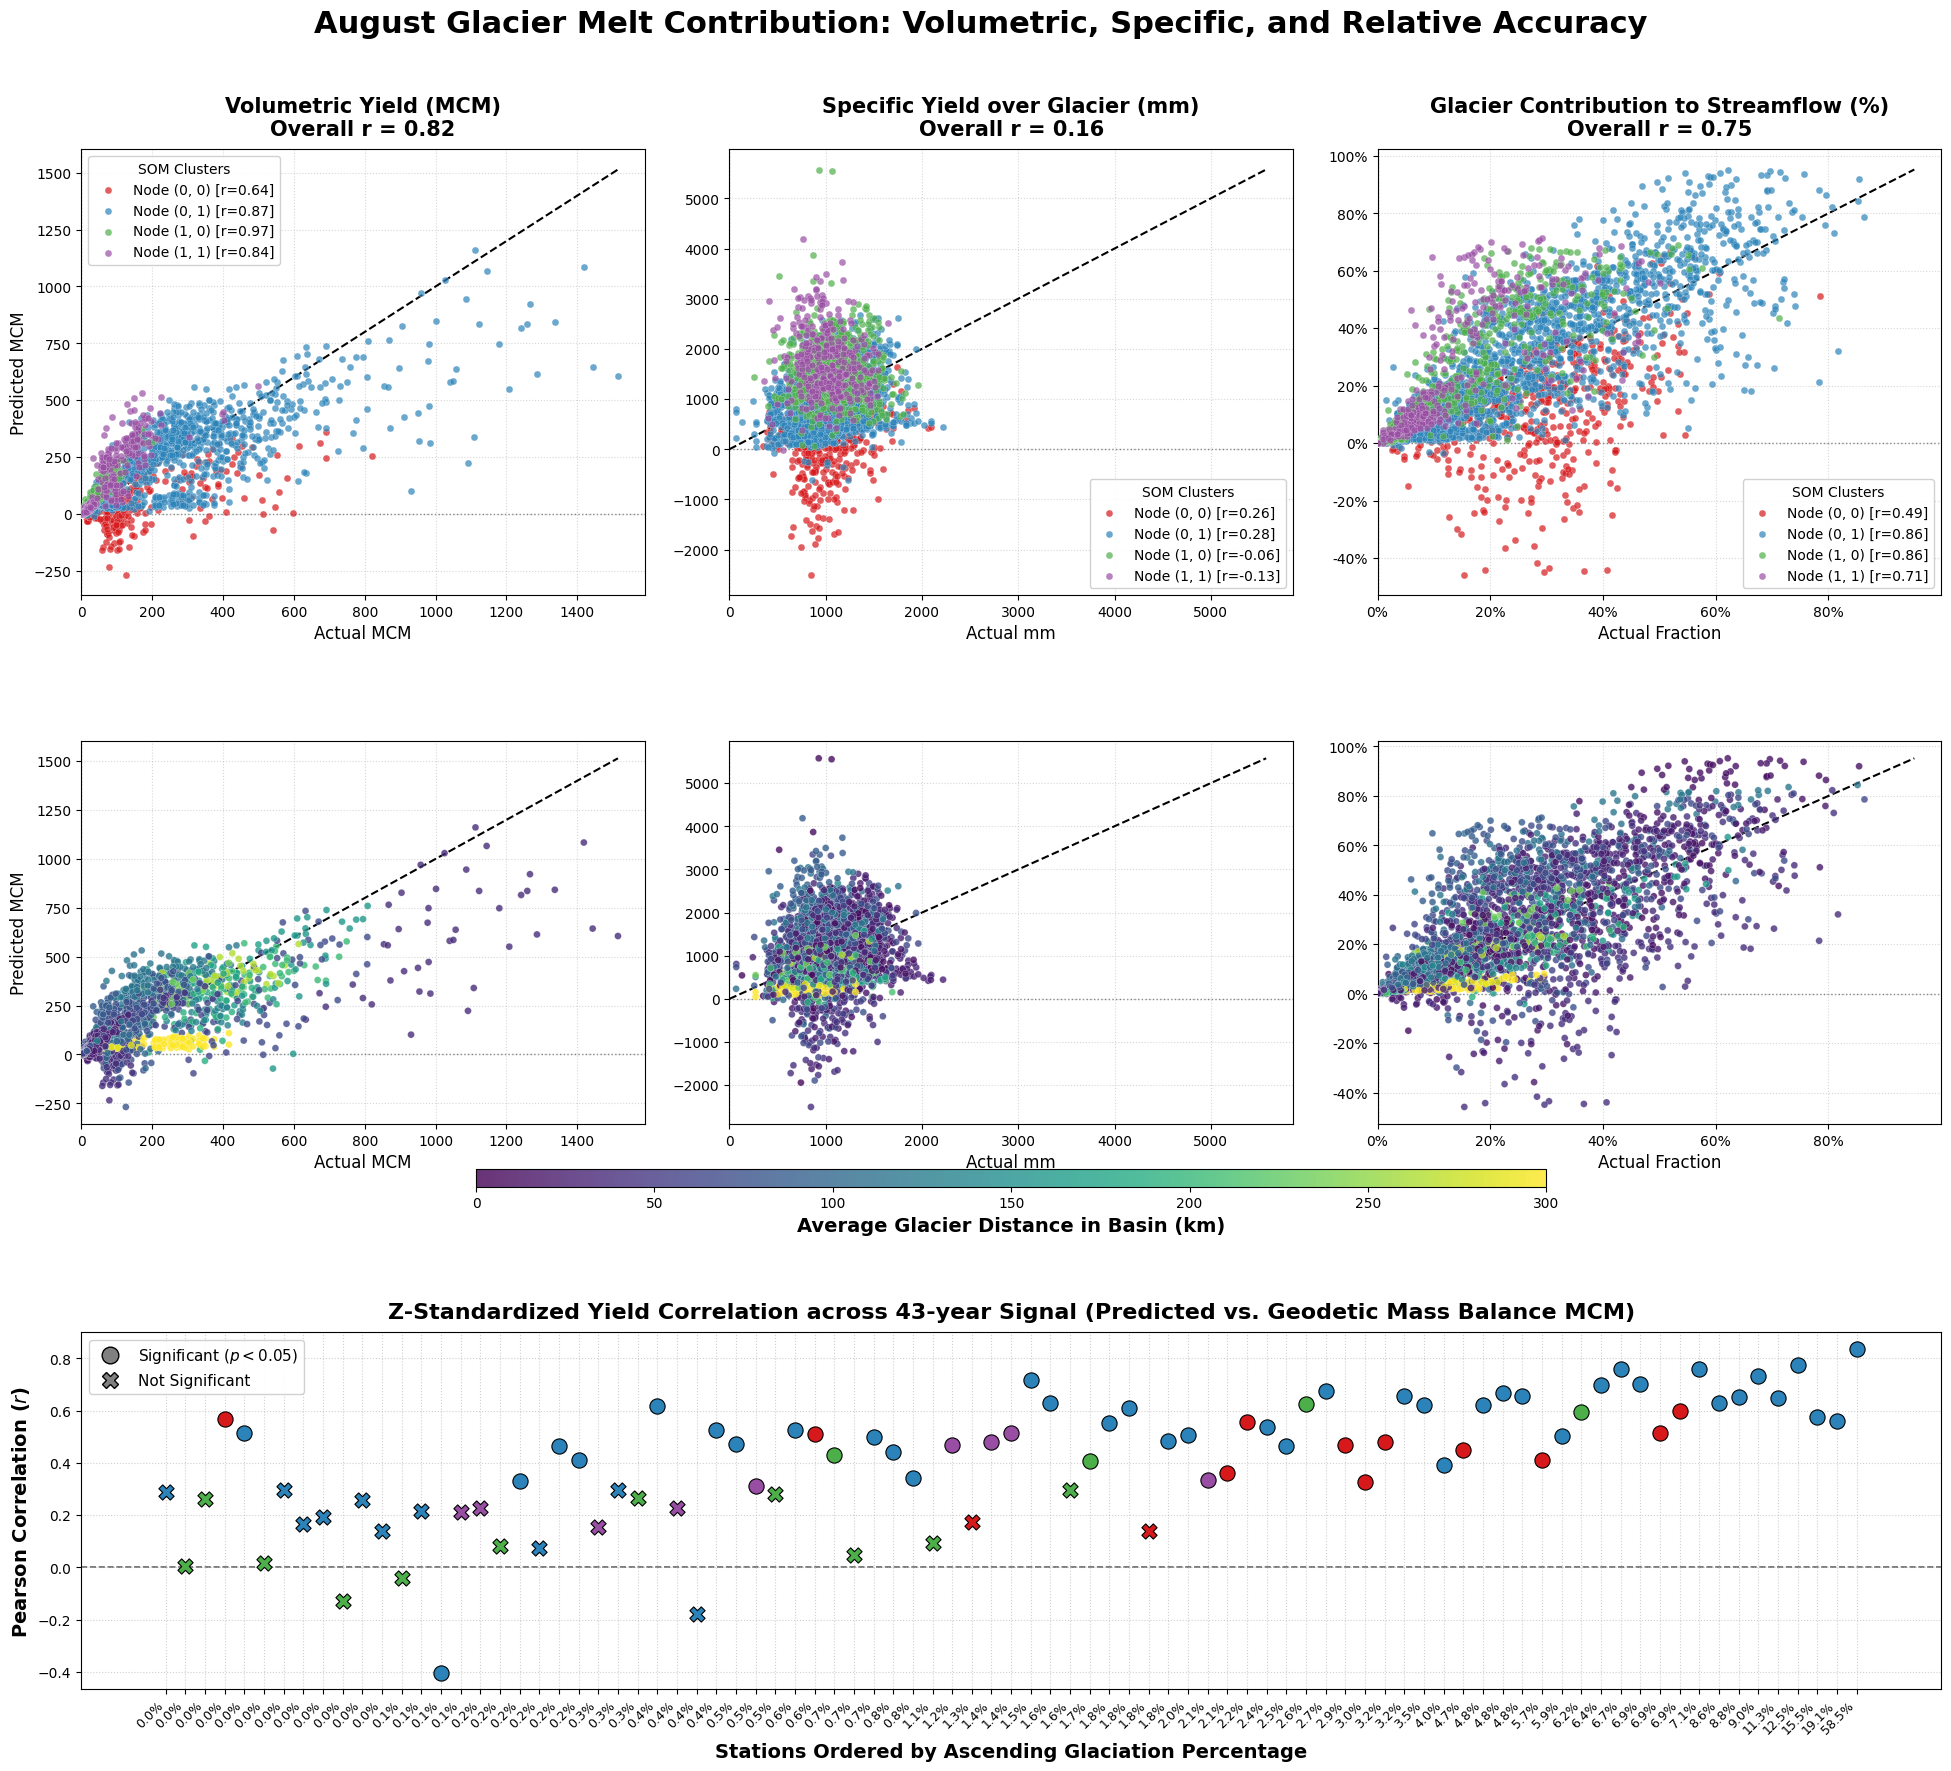

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr
import warnings
from matplotlib.lines import Line2D

warnings.filterwarnings('ignore')

MONTH = 8 # August

# Isolate August data
aug_mask_daily = (dq_pred.index.month == MONTH)
aug_mask_monthly = (mb_pred.index.month == MONTH)

# sum over august for each year and station and report in MCM, mm, and percentage of streamflow contribution
dq_pred_aug_sum = dq_pred[aug_mask_daily].groupby(dq_pred[aug_mask_daily].index.year).sum()
mb_pred_mcm_aug_sum = mb_pred[aug_mask_monthly].groupby(mb_pred[aug_mask_monthly].index.year).sum()
dq_pred_mcm_aug_sum = dq_pred_aug_sum * df_attr.loc[dq_pred_aug_sum.columns, 'basin_area_km2'] * 0.001
dq_pred_mm_glacier_aug_sum = dq_pred_mcm_aug_sum * 1000.0 / df_attr.loc[dq_pred_mcm_aug_sum.columns, 'glacier_area_km2']
mb_pred_mm_glacier_aug_sum = mb_pred_mcm_aug_sum * 1000.0 / df_attr.loc[mb_pred_mcm_aug_sum.columns, 'glacier_area_km2']
df_pred_glac = df_pred[glaciated_stations]

# Assuming q_obs_filtered is defined in your environment (or use df_obs)
q_obs_aug_sum = q_obs_filtered[aug_mask_daily].groupby(q_obs_filtered[aug_mask_daily].index.year).sum()

dq_pred_frac_aug_sum = dq_pred_aug_sum / df_pred_glac[aug_mask_daily].groupby(df_pred_glac[aug_mask_daily].index.year).sum()
mb_pred_frac_aug_sum = mb_pred_mcm_aug_sum / (q_obs_aug_sum * df_attr.loc[q_obs_aug_sum.columns, 'basin_area_km2'] * 0.001)

# =========================================================
# 3. Stack Data for Plotting
# =========================================================
print("Assembling plotting dataset...")

def stack_metric(df, name):
    stacked = df.stack().reset_index()
    stacked.columns = ['Year', 'Station', name]
    return stacked.set_index(['Year', 'Station'])

plot_df = pd.concat([
    stack_metric(dq_pred_mcm_aug_sum, 'Pred_MCM'),
    stack_metric(-mb_pred_mcm_aug_sum, 'Act_MCM'),
    stack_metric(dq_pred_mm_glacier_aug_sum, 'Pred_mm'),
    stack_metric(-mb_pred_mm_glacier_aug_sum, 'Act_mm'),
    stack_metric(dq_pred_frac_aug_sum, 'Pred_Pct'),
    stack_metric(-mb_pred_frac_aug_sum, 'Act_Pct')
], axis=1).reset_index()

# Merge SOM Clusters & Distance
df_som_clusters['Station'] = df_som_clusters['Station'].astype(str).str.strip().str.upper()

plot_df = pd.merge(plot_df, df_som_clusters[['Year', 'Station', 'Cluster']], on=['Year', 'Station'], how='inner')
plot_df = pd.merge(plot_df, df_attr[['avg_glacier_dist_km']], left_on='Station', right_index=True, how='inner')

# Clean up infinite/wild outliers for plot readability
plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna()
plot_df = plot_df[(plot_df['Pred_Pct'] >= -0.5) & (plot_df['Pred_Pct'] <= 1.5)]
plot_df = plot_df[(plot_df['Act_Pct'] >= -0.5) & (plot_df['Act_Pct'] <= 1.5)]

# =========================================================
# 4. Station-by-Station Standardized Correlations
# =========================================================
print("Calculating per-station Z-standardized correlations...")
station_corrs = []

for stat in plot_df['Station'].unique():
    stat_data = plot_df[plot_df['Station'] == stat]
    
    if len(stat_data) < 3: 
        continue # Require minimum sample size for correlation
        
    pred = stat_data['Pred_MCM'].values
    act = stat_data['Act_MCM'].values
    
    # Ensure neither vector has zero variance
    if np.std(pred) == 0 or np.std(act) == 0:
        continue
        
    # Z-Standardize the 43-year signal for this specific station
    z_pred = (pred - np.mean(pred)) / np.std(pred)
    z_act = (act - np.mean(act)) / np.std(act)
    
    # Calculate Pearson r and p-value on the standardized signals
    r_val, p_val = pearsonr(z_pred, z_act)
    
    glac_pct = df_attr.loc[stat, 'glacier_pct']
    cluster = stat_data['Cluster'].iloc[0]
    
    station_corrs.append({
        'Station': stat,
        'Glacier_Pct': glac_pct,
        'r': r_val,
        'Significant': p_val < 0.05,
        'Cluster': cluster
    })

# Sort ascending by glaciation percentage
df_station_corrs = pd.DataFrame(station_corrs).sort_values(by='Glacier_Pct').reset_index(drop=True)

# =========================================================
# 5. Plotting: The 3x3 Evaluation Grid
# =========================================================
print("Generating Scatter Grid...")

fig = plt.figure(figsize=(24, 20))
# Create GridSpec: Top two rows for the 2x3 layout, Bottom row spans all columns
gs = gridspec.GridSpec(3, 3, height_ratios=[1, 1, 0.8], hspace=0.35, wspace=0.15)

fig.suptitle("August Glacier Melt Contribution: Volumetric, Specific, and Relative Accuracy", fontsize=22, fontweight='bold', y=0.95)

cluster_colors = {0: '#d7191c', 1: '#2b83ba', 2: '#4daf4a', 3: '#984ea3'}

# Plot configs [Predicted Col, Actual Col, Title, Axis Label]
plot_configs = [
    ('Pred_MCM', 'Act_MCM', 'Volumetric Yield (MCM)', 'MCM'),
    ('Pred_mm', 'Act_mm', 'Specific Yield over Glacier (mm)', 'mm'),
    ('Pred_Pct', 'Act_Pct', 'Glacier Contribution to Streamflow (%)', 'Fraction')
]

vmax_dist = 300 # Cap heatmap outliers

axes = np.empty((2, 3), dtype=object)

for col_idx, config in enumerate(plot_configs):
    y_col, x_col, title, unit = config
    
    axes[0, col_idx] = fig.add_subplot(gs[0, col_idx])
    axes[1, col_idx] = fig.add_subplot(gs[1, col_idx])
    
    # Calculate overall correlation for column title
    overall_corr = plot_df[x_col].corr(plot_df[y_col])
    axes[0, col_idx].set_title(f"{title}\nOverall r = {overall_corr:.2f}", fontsize=15, fontweight='bold', pad=10)
    
    # ----------------------------------------------------
    # ROW 1: Colored by SOM Cluster
    # ----------------------------------------------------
    ax_top = axes[0, col_idx]
    
    for cluster_id in range(4):
        subset = plot_df[plot_df['Cluster'] == cluster_id]
        qx, qy = cluster_id // 2, cluster_id % 2
        
        if len(subset) > 1:
            r_val = subset[x_col].corr(subset[y_col])
            label = f'Node ({qx}, {qy}) [r={r_val:.2f}]'
        else:
            label = f'Node ({qx}, {qy}) [N={len(subset)}]'
            
        ax_top.scatter(
            subset[x_col], subset[y_col], 
            color=cluster_colors[cluster_id], alpha=0.7, edgecolors='white', linewidths=0.2, s=25, label=label, zorder=3
        )
        
    ax_top.legend(title="SOM Clusters", loc='best', framealpha=0.9, fontsize=10)

    # ----------------------------------------------------
    # ROW 2: Colored by Average Glacier Distance
    # ----------------------------------------------------
    ax_bot = axes[1, col_idx]
    
    scatter_bot = ax_bot.scatter(
        plot_df[x_col], plot_df[y_col], 
        c=plot_df['avg_glacier_dist_km'], cmap='viridis', 
        vmin=0, vmax=vmax_dist, 
        alpha=0.8, edgecolors='white', linewidths=0.2, s=25, zorder=3
    )

    # ----------------------------------------------------
    # Formatting applied to BOTH rows
    # ----------------------------------------------------
    for row_idx in [0, 1]:
        ax = axes[row_idx, col_idx]
        
        # 1:1 Line (Starts at 0 since Actuals are non-negative)
        max_val = max(plot_df[x_col].max(), plot_df[y_col].max())
        ax.plot([0, max_val], [0, max_val], color='black', linestyle='--', linewidth=1.5, zorder=2)
        
        # Zero Baselines
        ax.axhline(0, color='gray', linestyle=':', linewidth=1, zorder=1)
        ax.axvline(0, color='gray', linestyle=':', linewidth=1, zorder=1)
        
        # Limit X-axis to non-negative values (Actuals)
        ax.set_xlim(left=0)
        
        ax.set_xlabel(f"Actual {unit}", fontsize=12)
        if col_idx == 0:
            ax.set_ylabel(f"Predicted {unit}", fontsize=12)
            
        # Format percentages on the 3rd column
        if col_idx == 2:
            ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
            
        ax.grid(True, linestyle=':', alpha=0.5, zorder=0)

# Apply Colorbar to the bottom of Row 2 dynamically using the Grid axes array
cbar = fig.colorbar(scatter_bot, ax=[axes[1,0], axes[1,1], axes[1,2]], orientation='horizontal', fraction=0.04, pad=0.1, aspect=60)
cbar.set_label('Average Glacier Distance in Basin (km)', fontsize=14, fontweight='bold')

# ----------------------------------------------------
# ROW 3: Station-by-Station Ordered Correlation Plot
# ----------------------------------------------------
ax_span = fig.add_subplot(gs[2, :])

for i, row in df_station_corrs.iterrows():
    marker_shape = 'o' if row['Significant'] else 'X'
    c_color = cluster_colors[row['Cluster']]
    
    ax_span.scatter(i, row['r'], color=c_color, marker=marker_shape, s=120, edgecolors='black', linewidths=0.8, zorder=3)

# Define X-axis categorical labels
x_labels = [f"{row['Glacier_Pct']:.1f}%" for _, row in df_station_corrs.iterrows()]
ax_span.set_xticks(range(len(df_station_corrs)))
ax_span.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=9)

# Spanning plot formatting
ax_span.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.6, zorder=1)
ax_span.set_ylabel("Pearson Correlation ($r$)", fontsize=14, fontweight='bold')
ax_span.set_xlabel("Stations Ordered by Ascending Glaciation Percentage", fontsize=14, fontweight='bold')
ax_span.set_title("Z-Standardized Yield Correlation across 43-year Signal (Predicted vs. Geodetic Mass Balance MCM)", fontsize=16, fontweight='bold', pad=10)
ax_span.grid(True, linestyle=':', alpha=0.6, zorder=0)

# Custom legend for the spanning plot
legend_elements_span = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=12, markeredgecolor='k', label='Significant ($p < 0.05$)'),
    Line2D([0], [0], marker='X', color='w', markerfacecolor='gray', markersize=12, markeredgecolor='k', label='Not Significant')
]
ax_span.legend(handles=legend_elements_span, loc='upper left', framealpha=0.9, fontsize=11)

plt.show()

Supplementary: histogram of static attributes